In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

In [26]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

data = fetch_california_housing(as_frame=True)
X, y = data.data, data.target

display(data.frame.head())
display(data.frame.tail())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
display(X_train.shape, X_test.shape)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


(16512, 8)

(4128, 8)

In [17]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

baseline = DummyRegressor(strategy="mean").fit(X_train, y_train)
pred_baseline = baseline.predict(X_test)
mse_baseline = mean_squared_error(y_test, pred_baseline)
mae_baseline = mean_absolute_error(y_test, pred_baseline)

linear = LinearRegression().fit(X_train, y_train)
pred_linear = linear.predict(X_test)
mse_linear = mean_squared_error(y_test, pred_linear)
mae_linear = mean_absolute_error(y_test, pred_linear)

display(f"Baseline: MSE={mse_baseline:.3f} MAE={mae_baseline:.3f}")
display(f"Linear:   MSE={mse_linear:.3f} MAE={mae_linear:.3f}")

'Baseline: MSE=1.311 MAE=0.906'

'Linear:   MSE=0.556 MAE=0.533'

,MSE,MAE
baseline,1.310696,0.906069
linear,0.555892,0.533200
boosting,0.216596,0.311055


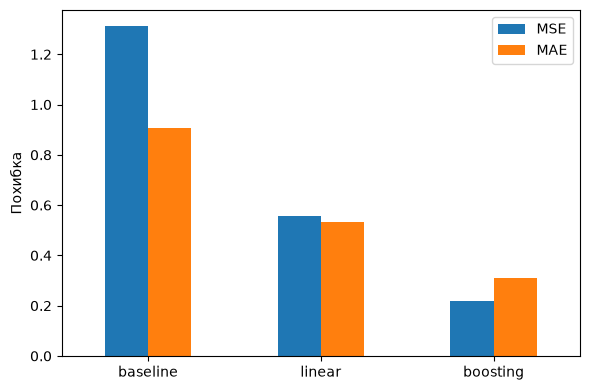

In [18]:
from sklearn.ensemble import HistGradientBoostingRegressor

boosted = HistGradientBoostingRegressor(random_state=42).fit(X_train, y_train)
pred_boosted = boosted.predict(X_test)
mse_boosted = mean_squared_error(y_test, pred_boosted)
mae_boosted = mean_absolute_error(y_test, pred_boosted)

comparison = pd.DataFrame(
    {"MSE": [mse_baseline, mse_linear, mse_boosted],
     "MAE": [mae_baseline, mae_linear, mae_boosted]},
    index=["baseline", "linear", "boosting"],
)
display(comparison)

comparison.plot(kind="bar", figsize=(6, 4))
plt.ylabel("Похибка")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

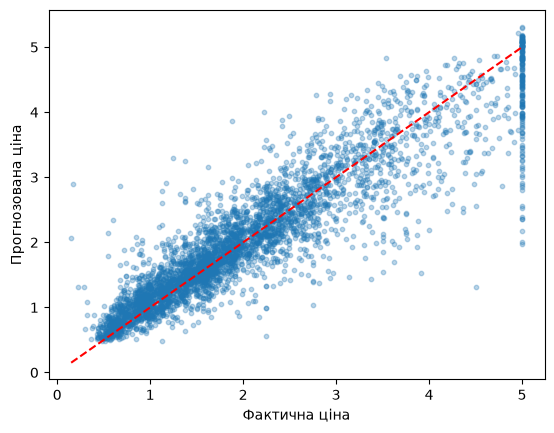

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,actual,predicted,abs_error
19542,1.7679,39.0,5.000000,0.888889,22.0,2.444444,37.63,-120.92,4.50000,1.311197,3.188803
12389,3.7727,24.0,10.953586,1.848101,473.0,1.995781,33.75,-116.43,5.00001,1.971517,3.028493
6688,0.4999,28.0,7.677419,1.870968,142.0,4.580645,34.15,-118.08,5.00001,2.010823,2.989187
459,1.1696,52.0,2.436000,0.944000,1349.0,5.396000,37.87,-122.25,5.00001,2.167562,2.832448
5887,2.3667,39.0,3.572464,1.217391,259.0,1.876812,34.15,-118.33,0.17500,2.899887,2.724887


In [19]:
plt.scatter(y_test, pred_boosted, alpha=0.3, s=10)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--")
plt.xlabel("Фактична ціна")
plt.ylabel("Прогнозована ціна")
plt.show()

results = X_test.copy()
results["actual"] = y_test.values
results["predicted"] = pred_boosted
results["abs_error"] = (results["predicted"] - results["actual"]).abs()
display(results.sort_values("abs_error", ascending=False).head(5))

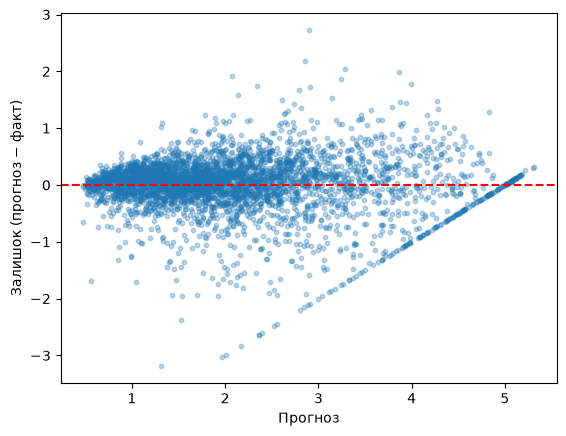

In [7]:
residuals = pred_boosted - y_test
plt.scatter(pred_boosted, residuals, alpha=0.3, s=10)
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("Прогноз")
plt.ylabel("Залишок (прогноз − факт)")
plt.show()

In [23]:
from sklearn.datasets import make_classification

X_c, y_c = make_classification(
    n_samples=5000, n_features=12, n_informative=6, n_redundant=2,
    weights=[0.9, 0.1], class_sep=1.0, flip_y=0.02, random_state=42
)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_c, y_c, test_size=0.2, stratify=y_c, random_state=42
)
print("full:", np.bincount(y_c))
print("train:", np.bincount(yc_train))
print("test:", np.bincount(yc_test))

full: [4463  537]
train: [3570  430]
test: [893 107]


In [28]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

baseline_clf = DummyClassifier(strategy="most_frequent").fit(Xc_train, yc_train)
pred_baseline_clf = baseline_clf.predict(Xc_test)
print(confusion_matrix(yc_test, pred_baseline_clf))
print(classification_report(yc_test, pred_baseline_clf, target_names=["stayed","churned"], zero_division=0))

logistic = LogisticRegression(max_iter=1000, random_state=42).fit(Xc_train, yc_train)
pred_logistic = logistic.predict(Xc_test)
print(classification_report(yc_test, pred_logistic, target_names=["stayed","churned"], zero_division=0))

[[893   0]
 [107   0]]
              precision    recall  f1-score   support

      stayed       0.89      1.00      0.94       893
     churned       0.00      0.00      0.00       107

    accuracy                           0.89      1000
   macro avg       0.45      0.50      0.47      1000
weighted avg       0.80      0.89      0.84      1000

              precision    recall  f1-score   support

      stayed       0.91      0.98      0.94       893
     churned       0.53      0.15      0.23       107

    accuracy                           0.90      1000
   macro avg       0.72      0.57      0.59      1000
weighted avg       0.87      0.90      0.87      1000



In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

tree = DecisionTreeClassifier(random_state=42).fit(Xc_train, yc_train)
forest = RandomForestClassifier(random_state=42).fit(Xc_train, yc_train)

for name, model in [("logistic", logistic), ("tree", tree), ("forest", forest)]:
    pred = model.predict(Xc_test)
    print(name, classification_report(yc_test, pred, target_names=["stayed","churned"], zero_division=0))

logistic               precision    recall  f1-score   support

      stayed       0.91      0.98      0.94       893
     churned       0.53      0.15      0.23       107

    accuracy                           0.90      1000
   macro avg       0.72      0.57      0.59      1000
weighted avg       0.87      0.90      0.87      1000

tree               precision    recall  f1-score   support

      stayed       0.95      0.95      0.95       893
     churned       0.58      0.54      0.56       107

    accuracy                           0.91      1000
   macro avg       0.76      0.75      0.75      1000
weighted avg       0.91      0.91      0.91      1000

forest               precision    recall  f1-score   support

      stayed       0.94      0.99      0.97       893
     churned       0.91      0.48      0.63       107

    accuracy                           0.94      1000
   macro avg       0.93      0.74      0.80      1000
weighted avg       0.94      0.94      0.93      1000

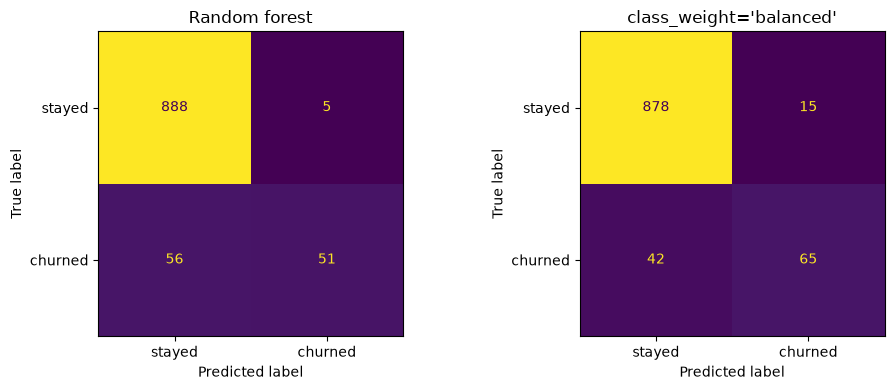

              precision    recall  f1-score   support

      stayed       0.95      0.98      0.97       893
     churned       0.81      0.61      0.70       107

    accuracy                           0.94      1000
   macro avg       0.88      0.80      0.83      1000
weighted avg       0.94      0.94      0.94      1000



In [30]:
forest_balanced = RandomForestClassifier(class_weight="balanced", random_state=42).fit(Xc_train, yc_train)
pred_forest_balanced = forest_balanced.predict(Xc_test)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_estimator(forest, Xc_test, yc_test, display_labels=["stayed","churned"], ax=axes[0], colorbar=False)
axes[0].set_title("Random forest")
ConfusionMatrixDisplay.from_estimator(forest_balanced, Xc_test, yc_test, display_labels=["stayed","churned"], ax=axes[1], colorbar=False)
axes[1].set_title("class_weight='balanced'")
plt.tight_layout()
plt.show()

print(classification_report(yc_test, pred_forest_balanced, target_names=["stayed","churned"], zero_division=0))

In [12]:
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(42)

def archetype(n, recency, frequency, monetary):
    return pd.DataFrame({
        "recency_days": np.clip(rng.normal(*recency, n), 0, None),
        "frequency": np.clip(rng.normal(*frequency, n), 0, None),
        "monetary": np.clip(rng.normal(*monetary, n), 0, None),
    })

champions  = archetype(150, (10, 5),   (18, 4),  (1200, 300))
at_risk    = archetype(150, (180, 40), (10, 3),  (900, 250))
bargain    = archetype(150, (120, 50), (2, 1),   (80, 30))
new_casual = archetype(150, (30, 15),  (4, 2),   (150, 50))

df = pd.concat([champions, at_risk, bargain, new_casual], ignore_index=True)
true_archetype = np.repeat([0, 1, 2, 3], 150)

print(df.describe().round(1))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[["recency_days", "frequency", "monetary"]])

       recency_days  frequency  monetary
count         600.0      600.0     600.0
mean           85.4        8.3     580.0
std            75.4        6.8     522.1
min             0.0        0.0       0.0
25%            13.5        2.6     102.9
50%            52.1        6.2     272.0
75%           149.6       13.2    1012.6
max           283.9       29.6    1898.3


'k=2 inertia=897.0 silhouette=0.502'

'k=3 inertia=406.8 silhouette=0.584'

'k=4 inertia=261.9 silhouette=0.576'

'k=5 inertia=223.0 silhouette=0.503'

'k=6 inertia=192.9 silhouette=0.453'

'k=7 inertia=174.3 silhouette=0.452'

'k=8 inertia=158.2 silhouette=0.398'

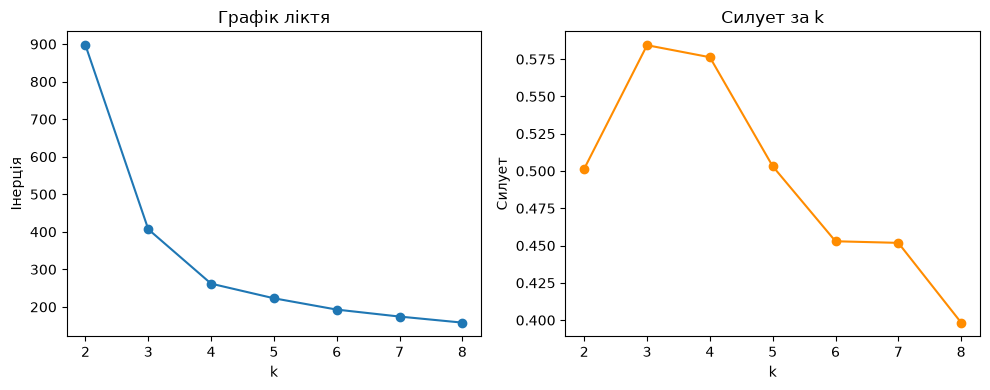

In [31]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias, sils = [], []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    sil = silhouette_score(X_scaled, km.labels_)
    inertias.append(km.inertia_)
    sils.append(sil)
    display(f"k={k} inertia={km.inertia_:.1f} silhouette={sil:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(range(2, 9), inertias, marker="o")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Інерція"); axes[0].set_title("Графік ліктя")
axes[1].plot(range(2, 9), sils, marker="o", color="darkorange")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Силует"); axes[1].set_title("Силует за k")
plt.tight_layout()
plt.show()

,recency_days,frequency,monetary
cluster,,,
0,179.4,9.7,902.0
1,34.6,3.5,132.8
2,10.1,17.8,1207.9
3,140.0,2.2,88.4


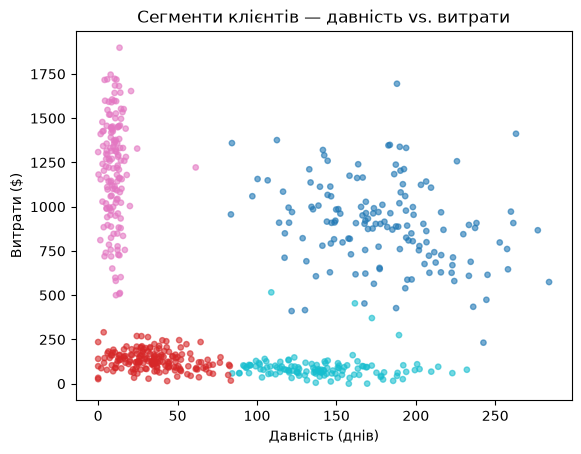

In [32]:
km4 = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_scaled)
df["cluster"] = km4.labels_
display(df.groupby("cluster")[["recency_days", "frequency", "monetary"]].mean().round(1))

plt.scatter(df["recency_days"], df["monetary"], c=df["cluster"], cmap="tab10", alpha=0.6, s=15)
plt.xlabel("Давність (днів)")
plt.ylabel("Витрати ($)")
plt.title("Сегменти клієнтів — давність vs. витрати")
plt.show()

In [33]:
from sklearn.cluster import DBSCAN

for eps in [0.3, 0.5, 0.7]:
    db = DBSCAN(eps=eps, min_samples=10).fit(X_scaled)
    n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    n_noise = (db.labels_ == -1).sum()
    display(f"eps={eps}: clusters={n_clusters} noise={n_noise}")

'eps=0.3: clusters=5 noise=156'

'eps=0.5: clusters=3 noise=25'

'eps=0.7: clusters=2 noise=3'

In [36]:
random_labels = rng.integers(0, 4, size=len(df))
print("random silhouette:", silhouette_score(X_scaled, random_labels))
print("k=4 silhouette:", silhouette_score(X_scaled, km4.labels_))

from sklearn.metrics import adjusted_rand_score
print("ARI vs true archetype:", adjusted_rand_score(true_archetype, km4.labels_))

random silhouette: -0.025563831796795885
k=4 silhouette: 0.5762993257557841
ARI vs true archetype: 0.8634522310545767
